In [37]:
# importing libraries
import pandas as pd # for reading csv and excel files, handling dataset
import numpy as np # for performing mathematical operations
import matplotlib.pyplot as plt # for graphical visualization
import seaborn as sns # for statistical visualization
from sklearn.preprocessing import LabelEncoder, StandardScaler #  feature encoding and scaling
from sklearn.model_selection import train_test_split # splitting dataset into train and test
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score # for model evaluation
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier # for model building
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [38]:
#loading dataset
df = pd.read_excel(r"C:\Users\rasika\Downloads\glass.xlsx")
df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [39]:
# Dataset Summary
df.info() # display number of entries, number of columns and their datatype.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


In [40]:
# summary statistics
df.describe() 

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
count,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000
mean,1.518365,13.407850,2.684533,1.444907,72.650935,0.497056,8.956963,0.175047,0.057009,2.780374
std,0.003037,0.816604,1.442408,0.499270,0.774546,0.652192,1.423153,0.497219,0.097439,2.103739
min,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,0.000000,1.000000
25%,1.516522,12.907500,2.115000,1.190000,72.280000,0.122500,8.240000,0.000000,0.000000,1.000000
50%,1.517680,13.300000,3.480000,1.360000,72.790000,0.555000,8.600000,0.000000,0.000000,2.000000
75%,1.519157,13.825000,3.600000,1.630000,73.087500,0.610000,9.172500,0.000000,0.100000,3.000000
max,1.533930,17.380000,4.490000,3.500000,75.410000,6.210000,16.190000,3.150000,0.510000,7.000000


In [41]:
# checking for missing values
df.isnull().sum()

RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

In [42]:
# checking for duplicates
df.duplicated().sum()

np.int64(1)

In [43]:
# Removing duplicate
df.drop_duplicates(inplace = True)

In [44]:
# checking for duplicates
df.duplicated().sum()

np.int64(0)

### Histogram for frequency distribution of numerical columns and skewness

array([[<Axes: title={'center': 'RI'}>, <Axes: title={'center': 'Na'}>,
        <Axes: title={'center': 'Mg'}>],
       [<Axes: title={'center': 'Al'}>, <Axes: title={'center': 'Si'}>,
        <Axes: title={'center': 'K'}>],
       [<Axes: title={'center': 'Ca'}>, <Axes: title={'center': 'Ba'}>,
        <Axes: title={'center': 'Fe'}>],
       [<Axes: title={'center': 'Type'}>, <Axes: >, <Axes: >]],
      dtype=object)

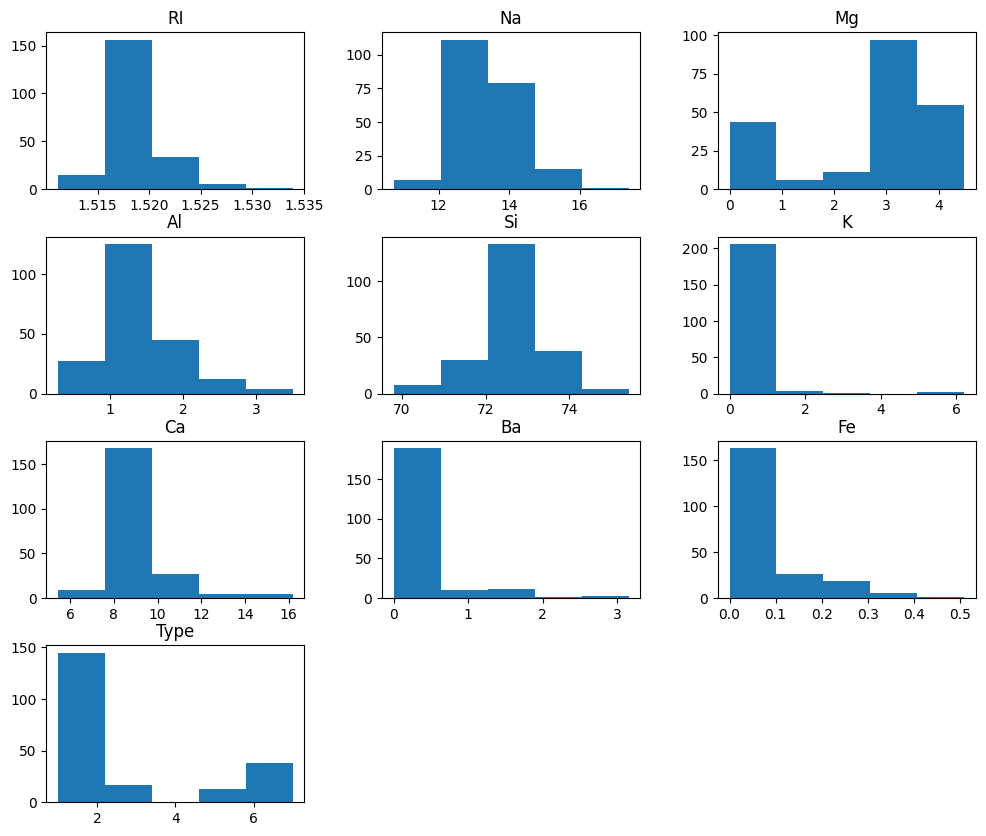

In [45]:
df.hist(bins = 5, grid = False, figsize = (12, 10))

1. RI, Na, AL, K, Ca, Ba, Fe are positively skewed.
2. K, Ba, Fe have most data distributed across 0.
3. Mg is negatively skewed and have most data distributed between 2.8 and 3.5
4. Si is normally distributed as it is almost in bell shape form
5. Type is target column positively skewed shows that most of the classes are of type 2 

### Boxplot for outlier detection

<Axes: >

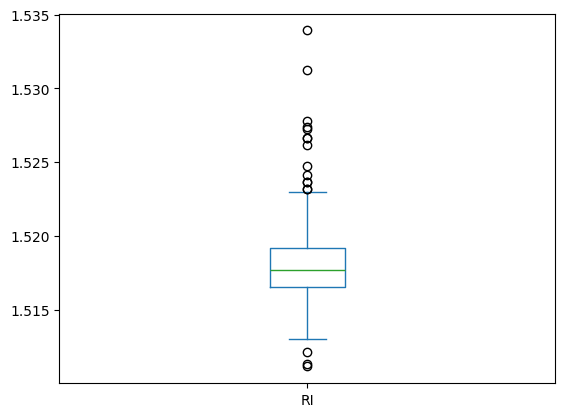

In [46]:
df['RI'].plot(kind = 'box')

<Axes: >

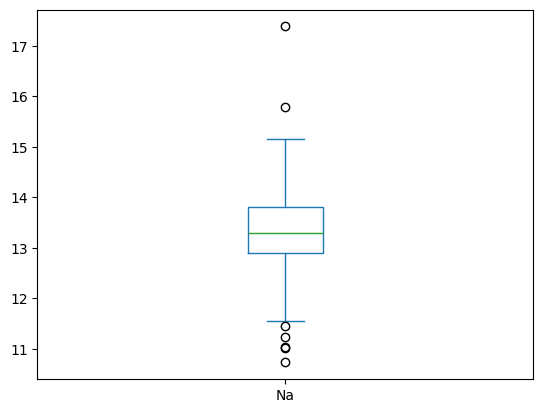

In [47]:
df['Na'].plot(kind = 'box')

<Axes: >

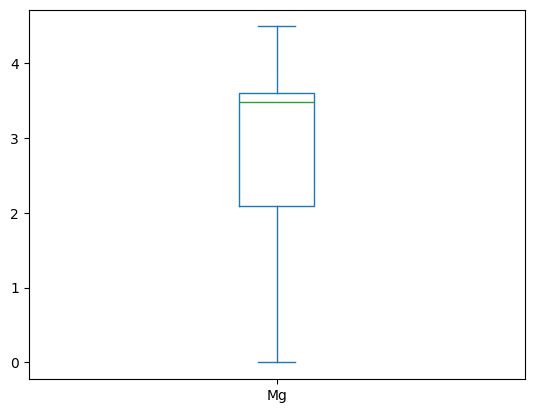

In [48]:
df['Mg'].plot(kind = 'box')

<Axes: >

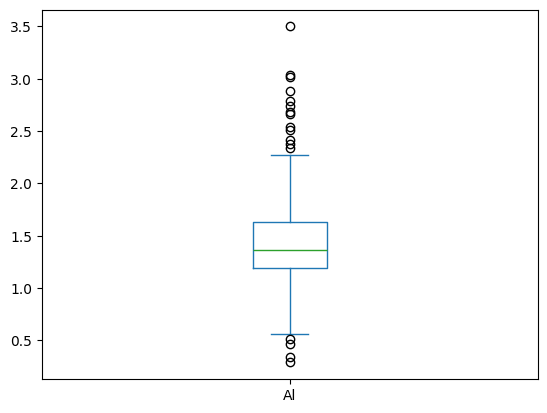

In [49]:
df['Al'].plot(kind = 'box')

<Axes: >

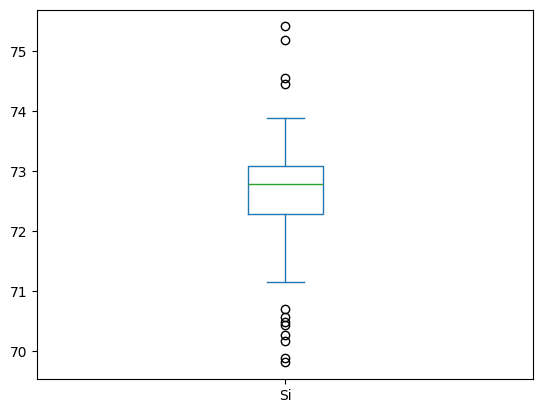

In [50]:
df['Si'].plot(kind = 'box')

<Axes: >

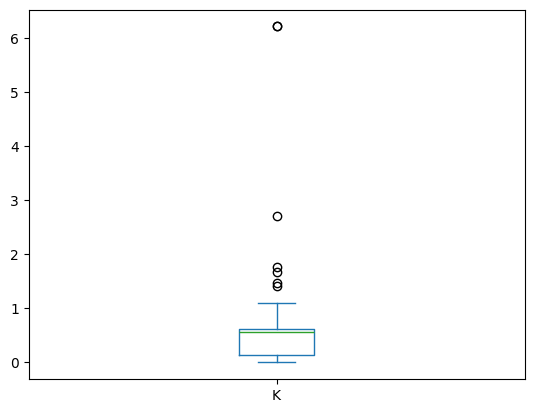

In [51]:
df['K'].plot(kind = 'box')

<Axes: >

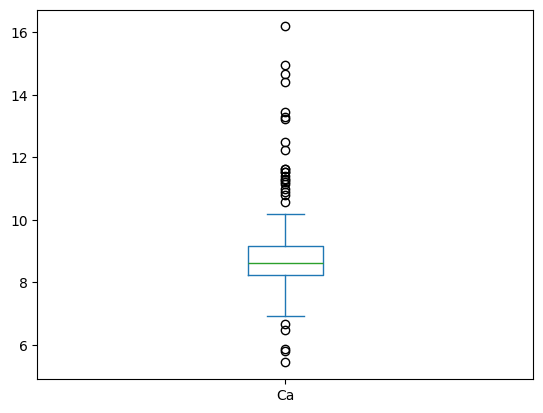

In [52]:
df['Ca'].plot(kind = 'box')

<Axes: >

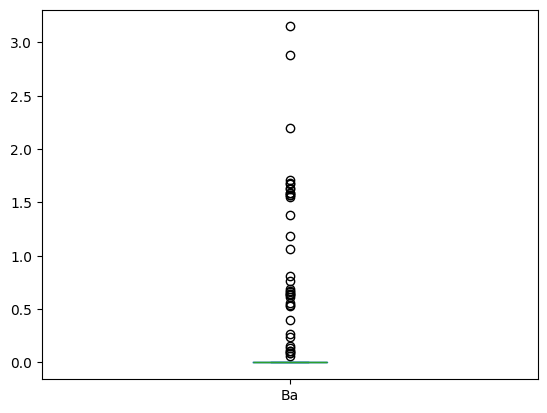

In [53]:
df['Ba'].plot(kind = 'box')

<Axes: >

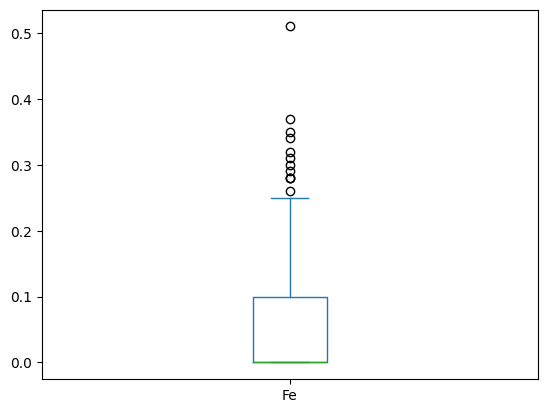

In [54]:
df['Fe'].plot(kind = 'box')

#### Outlier removal
Boxplots indicate the presence of outliers in several features. Since the Glass dataset contains genuine measurements from different glass categories and Random Forest is robust to outliers, the outliers were retained rather than removed.

### pairplot show distribution and relationship among features

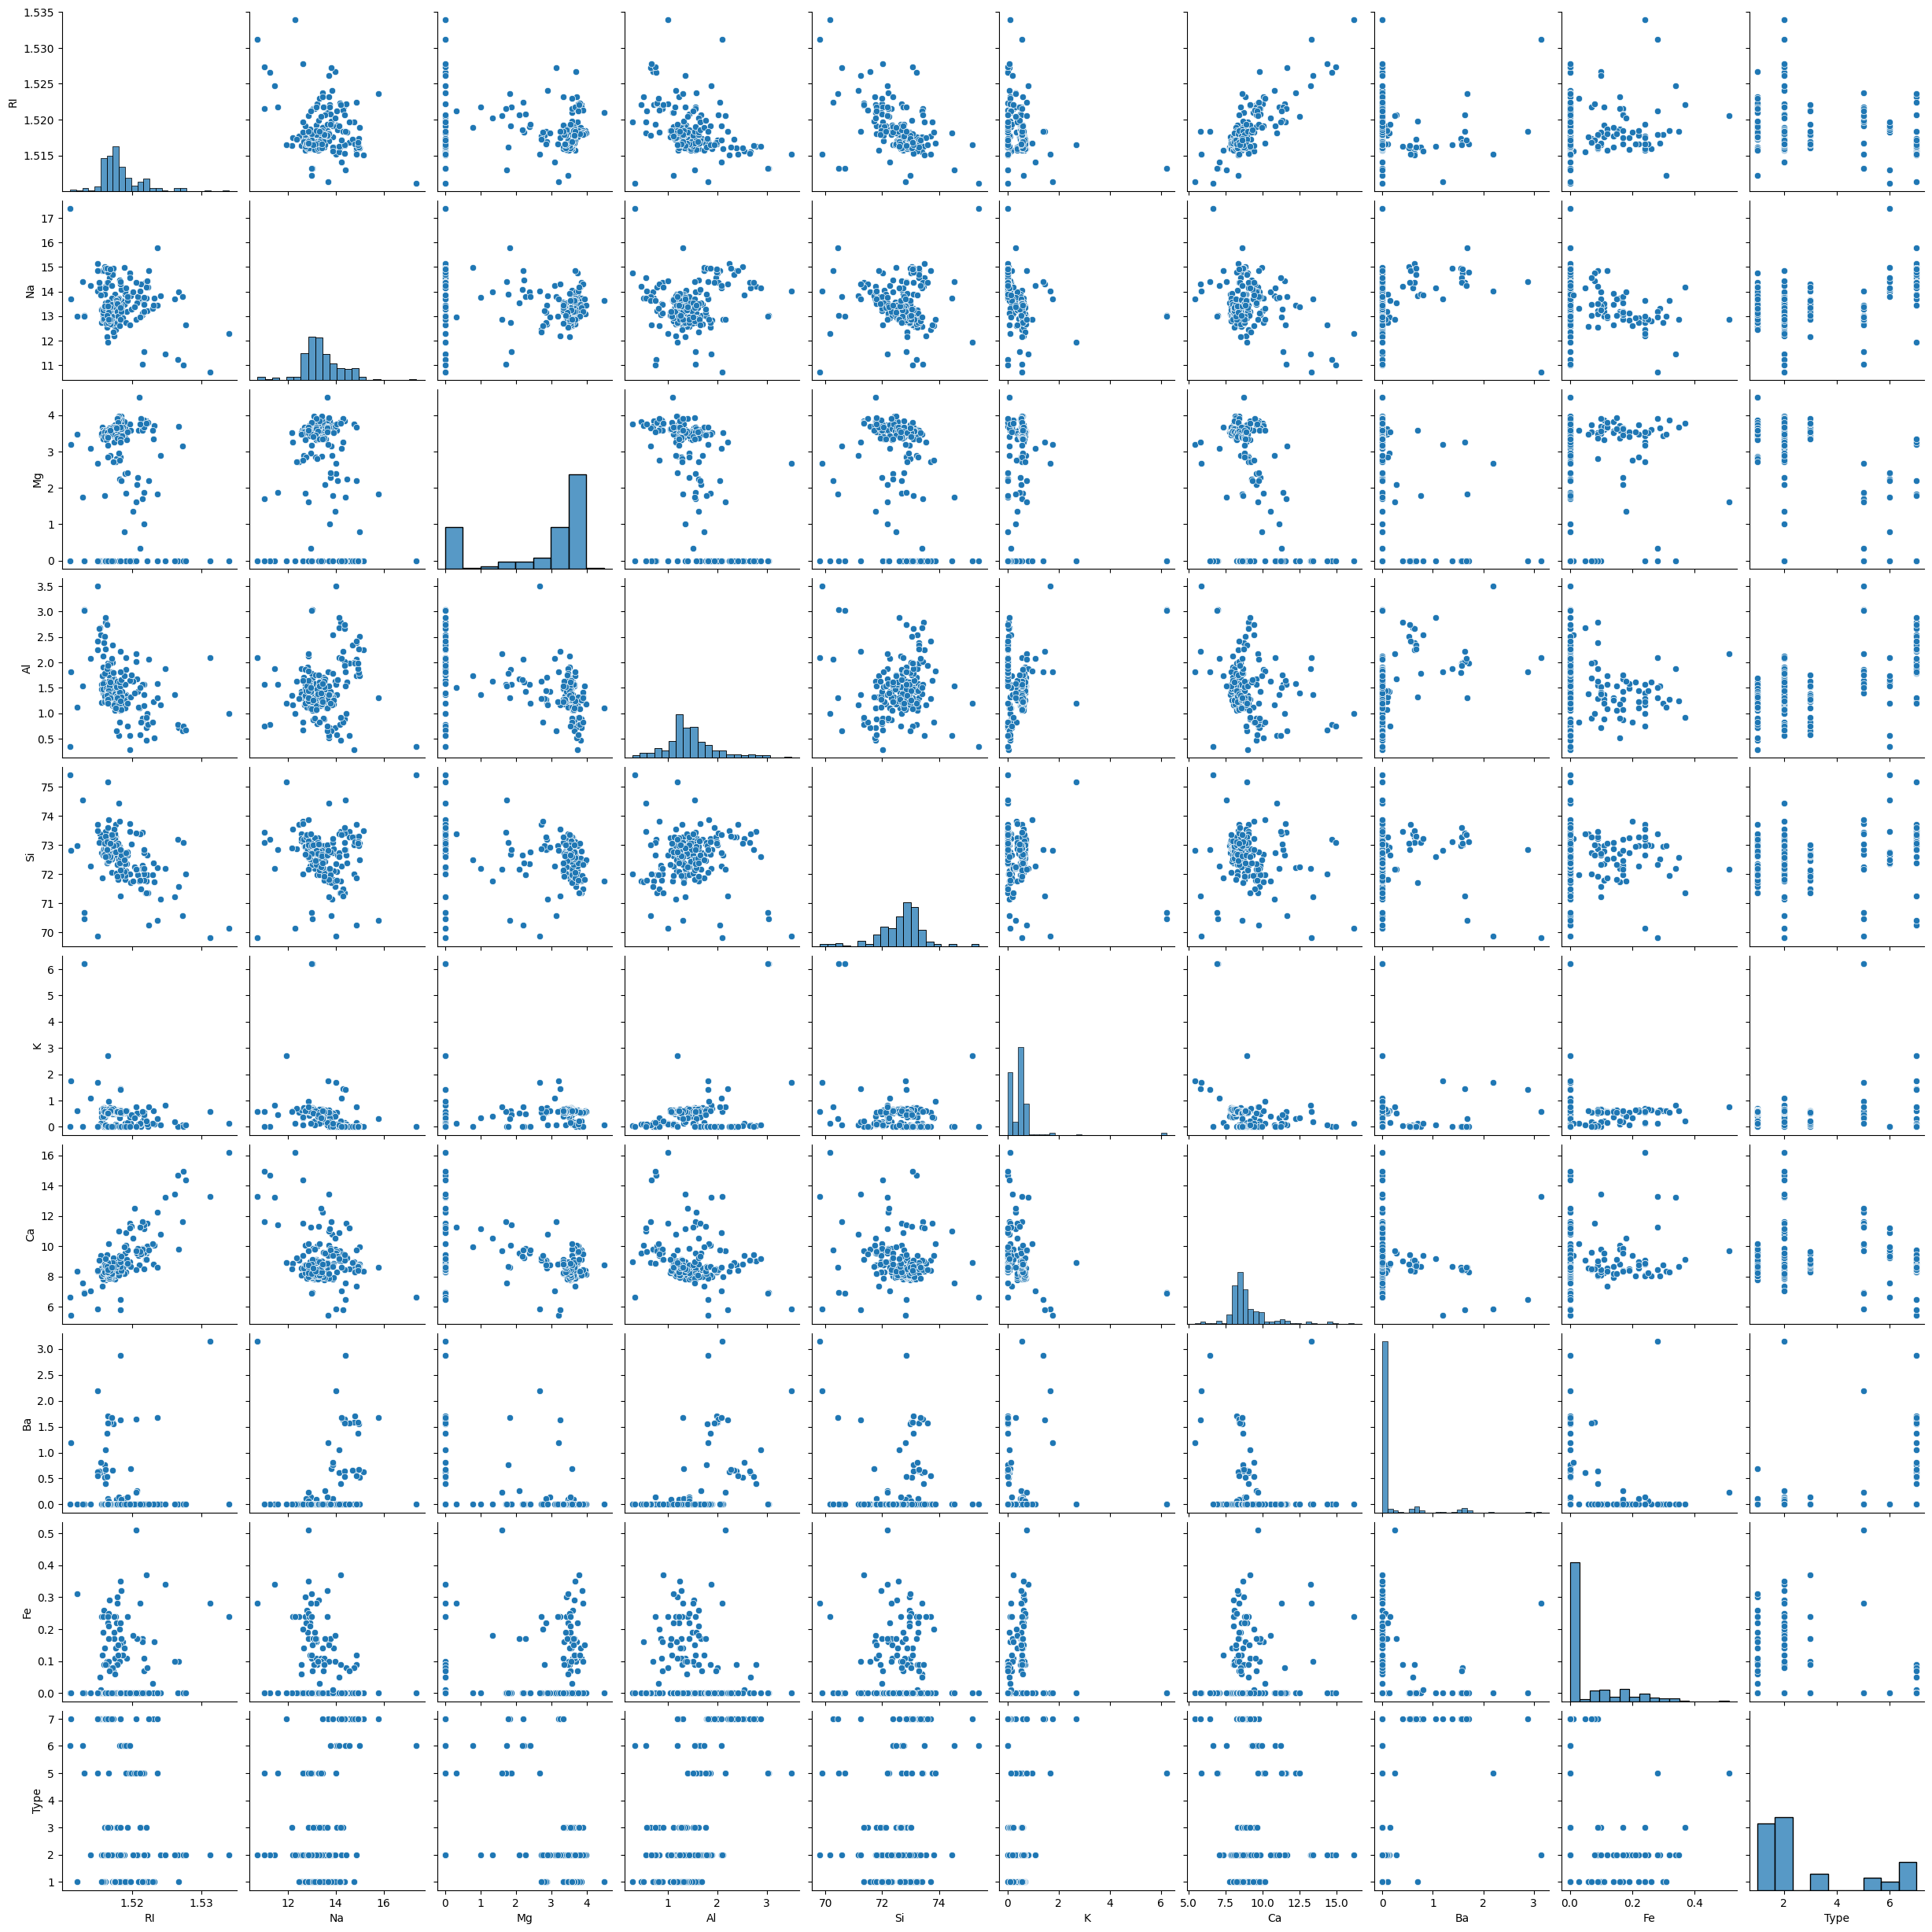

In [55]:
sns.pairplot(data = df)

### Heatmap shows correlation among features

<Axes: >

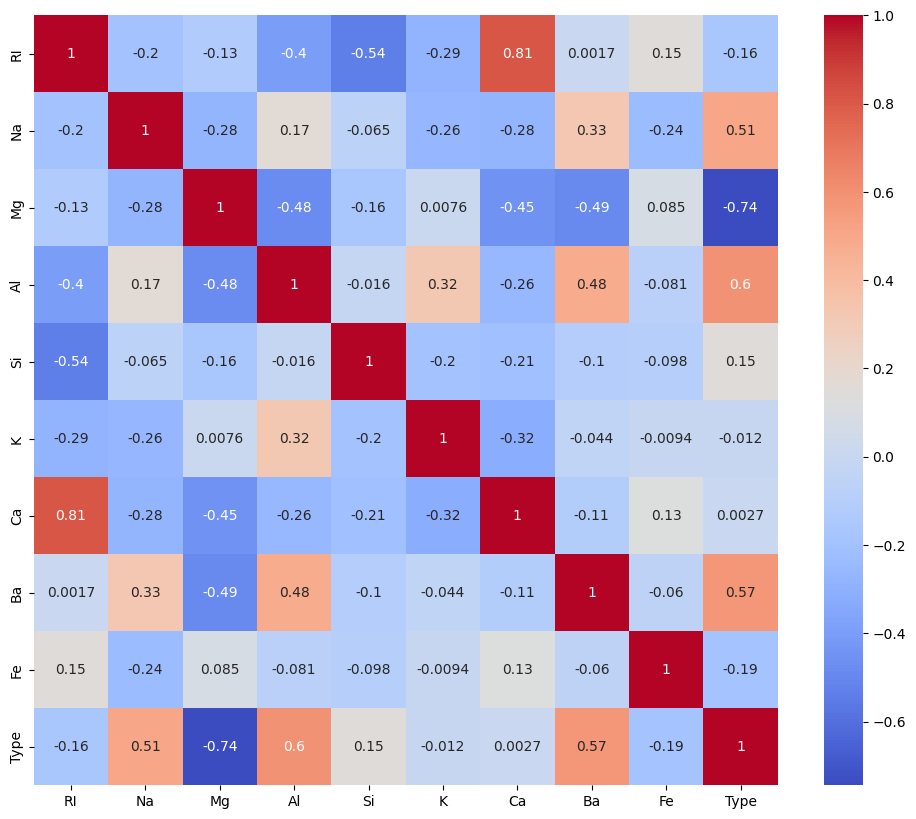

In [56]:
plt.figure(figsize = (12, 10))
sns.heatmap(df.corr(), annot = True, cmap = 'coolwarm')

#### from above heatmap it shows that RI is strongly correlated with Ca and no other features are strongly correlated

#### There is no categorical feature is in dataset so feature encoding is not required

In [57]:
# Feature Scaling 
sc = StandardScaler()
x_sc = sc.fit_transform(df)
x_sc

array([[ 0.87984017,  0.28955813,  1.25723832, ..., -0.35380764,
        -0.58830108, -0.85170346],
       [-0.24381562,  0.59640332,  0.63931074, ..., -0.35380764,
        -0.58830108, -0.85170346],
       [-0.71641202,  0.15454625,  0.6045957 , ..., -0.35380764,
        -0.58830108, -0.85170346],
       ...,
       [ 0.76086485,  1.17327228, -1.86017161, ...,  2.94550057,
        -0.58830108,  2.0051916 ],
       [-0.60735132,  1.19781989, -1.86017161, ...,  2.80467644,
        -0.58830108,  2.0051916 ],
       [-0.40905912,  1.01371278, -1.86017161, ...,  3.00585377,
        -0.58830108,  2.0051916 ]], shape=(213, 10))

In [58]:
# Assigning Features a variable 
X = df.drop('Type', axis = 1)
y = df['Type']

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

### Model Building
### RandomForestClassifier

In [59]:
rf = RandomForestClassifier(n_estimators = 100, random_state = 42, max_depth = 5, max_features = 0.7, max_samples = 0.6, min_samples_split = 10)

#training model
rf.fit(X_train, y_train)

# prediction for training data and unseen test data
y_pred_train = rf.predict(X_train)
y_pred_test = rf.predict(X_test)

### Model Evaluation

In [60]:
training_accuracy = accuracy_score(y_train, y_pred_train)
testing_accuracy = accuracy_score(y_test, y_pred_test)
precision = precision_score(y_test, y_pred_test, average = 'weighted')
recall = recall_score(y_test, y_pred_test, average = 'weighted')
f1 = f1_score(y_test, y_pred_test, average = 'weighted')

print('Training Accuracy :', training_accuracy)
print('Testing Accuracy :', testing_accuracy)
print('Precision Score :', precision)
print('Recall Score :', recall)
print('F1 Score :', f1)

Training Accuracy : 0.8470588235294118
Testing Accuracy : 0.813953488372093
Precision Score : 0.8255813953488372
Recall Score : 0.813953488372093
F1 Score : 0.8069767441860466


### Bagging

In [61]:
bagging_model = BaggingClassifier(
    estimator = DecisionTreeClassifier(criterion = 'gini', max_depth = 5, min_samples_split = 10),
    n_estimators = 100,
    random_state = 42,
    max_features = 0.7, 
    max_samples = 0.6,
)

bagging_model.fit(X_train, y_train)

y_pred_train_bagging = bagging_model.predict(X_train)
y_pred_test_bagging = bagging_model.predict(X_test)

### Model Evaluation

In [62]:
training_accuracy_bagging = accuracy_score(y_train, y_pred_train_bagging)
testing_accuracy_bagging = accuracy_score(y_test, y_pred_test_bagging)
precision_bagging = precision_score(y_test, y_pred_test_bagging, average = 'weighted')
recall_bagging = recall_score(y_test, y_pred_test_bagging, average = 'weighted')
f1_bagging = f1_score(y_test, y_pred_test_bagging, average = 'weighted')

print('Training Accuracy :', np.round(training_accuracy_bagging, 2))
print('Testing Accuracy :', np.round(testing_accuracy_bagging, 2))
print('Precision Score :', np.round(precision_bagging, 2))
print('Recall Score :', np.round(recall_bagging, 2))
print('F1 Score :', np.round(f1_bagging, 2))

Training Accuracy : 0.86
Testing Accuracy : 0.81
Precision Score : 0.83
Recall Score : 0.81
F1 Score : 0.8


In [63]:
from sklearn.model_selection import GridSearchCV

bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(
        criterion='gini',
        max_depth=5,
        min_samples_split=10
    ),
    random_state=42
)

param_grid = {
    'n_estimators': [100, 150],
    'max_samples': [0.7, 0.8],
    'max_features': [0.7, 0.8],
    # tuning the Decision Tree inside Bagging 
    'estimator__max_depth': [5, 7],
    'estimator__min_samples_split': [10, 15],
    'estimator__min_samples_leaf': [1, 2, 5]
}

# GridSearchCV
grid_search = GridSearchCV(
    estimator=bagging_model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Fit model
grid_search.fit(X_train, y_train)

# Best results
print("Best hyperparameters:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)

# Evaluate best model
best_bagging_model = grid_search.best_estimator_
y_pred_train_best = best_bagging_model.predict(X_train)
y_pred_test_best = best_bagging_model.predict(X_test)
print("Train accuracy:", accuracy_score(y_train, y_pred_train_best))
print("Test accuracy:", accuracy_score(y_test, y_pred_test_best))

Best hyperparameters: {'estimator__max_depth': 5, 'estimator__min_samples_leaf': 2, 'estimator__min_samples_split': 10, 'max_features': 0.8, 'max_samples': 0.8, 'n_estimators': 100}
Best score: 0.7352941176470589
Train accuracy: 0.8529411764705882
Test accuracy: 0.8372093023255814


### Boosting AdaBoostClassifier

In [82]:
boosting = AdaBoostClassifier(n_estimators = 100, random_state = 42)

boosting.fit(X_train, y_train)

y_pred_boost_train = boosting.predict(X_train)
y_pred_boost_test = boosting.predict(X_test)

### Model Evaluation

In [83]:
training_accuracy_boosting = accuracy_score(y_train, y_pred_boost_train)
testing_accuracy_boosting = accuracy_score(y_test, y_pred_boost_test)
precision_boosting = precision_score(y_test, y_pred_boost_test, average = 'weighted', zero_division = 0)
recall_boosting = recall_score(y_test, y_pred_boost_test, average = 'weighted')
f1_boosting = f1_score(y_test, y_pred_boost_test, average = 'weighted')

print('Training Accuracy :', np.round(training_accuracy_boosting, 2))
print('Testing Accuracy :', np.round(testing_accuracy_boosting, 2))
print('Precision Score :', np.round(precision_boosting, 2))
print('Recall Score :', np.round(recall_boosting, 2))
print('F1 Score :', np.round(f1_boosting, 2))

Training Accuracy : 0.47
Testing Accuracy : 0.4
Precision Score : 0.39
Recall Score : 0.4
F1 Score : 0.39


In [84]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators' : [50, 100, 200],
    'learning_rate' : [0.01, 0.1, 1, 10]
}

# GridSearchCV
grid_search = GridSearchCV(
    estimator=boosting,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Fit model
grid_search.fit(X_train, y_train)

# Best results
print("Best hyperparameters:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)

# Evaluate best model
best_boosting = grid_search.best_estimator_
y_pred_train_best_boost = best_boosting.predict(X_train)
y_pred_test_best_boost = best_boosting.predict(X_test)
print("Train accuracy:", accuracy_score(y_train, y_pred_train_best_boost))
print("Test accuracy:", accuracy_score(y_test, y_pred_test_best_boost))

Best hyperparameters: {'learning_rate': 1, 'n_estimators': 200}
Best score: 0.5411764705882354
Train accuracy: 0.4764705882352941
Test accuracy: 0.4186046511627907


#### Adaboost Showing less accuracy because it it sensitive to small size dataset(214 rows) and also have missclassification in datasett for target column have 7 classes with few are highly distributed and few are 9, 13

### Model Comparision

In [85]:
print('RandomForestClassifier',testing_accuracy)
print("BaggingClassifier:", accuracy_score(y_test, y_pred_test_best))
print('AdaBoostClassifier :', np.round(testing_accuracy_boosting, 2))

RandomForestClassifier 0.813953488372093
BaggingClassifier: 0.8372093023255814
AdaBoostClassifier : 0.4


#### BaggingClassifier gives better model accuracy with better generalization

#####
Additional Notes:
1. Explain Bagging and Boosting methods. How is it different from each other.

   Bagging is one of the ensemble technique used to improve accuracy and reduce overfitting. It trains subsets of dataset independently and then improve prediction accuracy by using bootstrap aggregation(majority voting for classification and average for regression).It perform parallely. It reduces overfitting, variance. Works well with large dataset.

   Boosting work sequentially. It assign samples from original dataset to different model and errors from previous model will be considered in next model. It will not always try to reduce error in next model it may give more errors. It reduces overfitting, variance.
   
   There are different boosting techniques:
   
        1. Adaboost : Assign weights to data and handles missclassification.
        2. GradientBoostMachine : Reduces error by updating weights. Will reduce residuel by selecting weak learner for              new model.
        3. XGBoost : work same as GBM but gives best accuracy as it is advanced technique with better generalization ,                 scalability

The major difference between Bagging and boosting is bagging work parallely that it will train model on samples and errors will be handled in that model only or will be kept as it is but in boosting errors will be handled in next model.

2. Explain how to handle imbalance in the data.

   Data is imbalanced when one class have many samples than other class. like here in Glass dataset some glass types are more but few are very less

   If data imbalance is not much use class weights method.

   For moderate imbalance can use SMOTE (Synthetic Minority Oversampling Technique)).

   For Severe imbalance use both class weights and SMOTE

   Either increase values in class with minimum data as class with more data or decrease values in class with maximum data as per class with less data
